# 🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations
## 📌 Project Overview
This notebook contains the complete **Data Science and Machine Learning** pipeline for the Shopper Spectrum E-Commerce project.
The deliverables include:
* **Data Cleaning & Feature Engineering**
* **Exploratory Data Analysis (EDA) & Visualizations**
* **RFM Customer Segmentation (K-Means Clustering) with Evaluation**
* **Collaborative Filtering for Product Recommendations**


In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1️⃣ Data Collection and Understanding
Load the dataset and preview its structure.


In [2]:
# Load dataset
df = pd.read_csv('dataset.csv', encoding='unicode_escape')
display(df.head())
display(df.info())


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


None

## 2️⃣ Data Preprocessing
* Remove missing CustomerIDs
* Exclude cancelled invoices
* Remove negative quantities and prices


In [3]:
# Remove missing CustomerID
df_clean = df.dropna(subset=['CustomerID']).copy()

# Remove cancelled invoices (starting with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative/zero quantities and prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Convert Date
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")


Original shape: (541909, 8)
Cleaned shape: (397884, 9)


## 3️⃣ Exploratory Data Analysis (EDA)
### Transaction Volume by Country


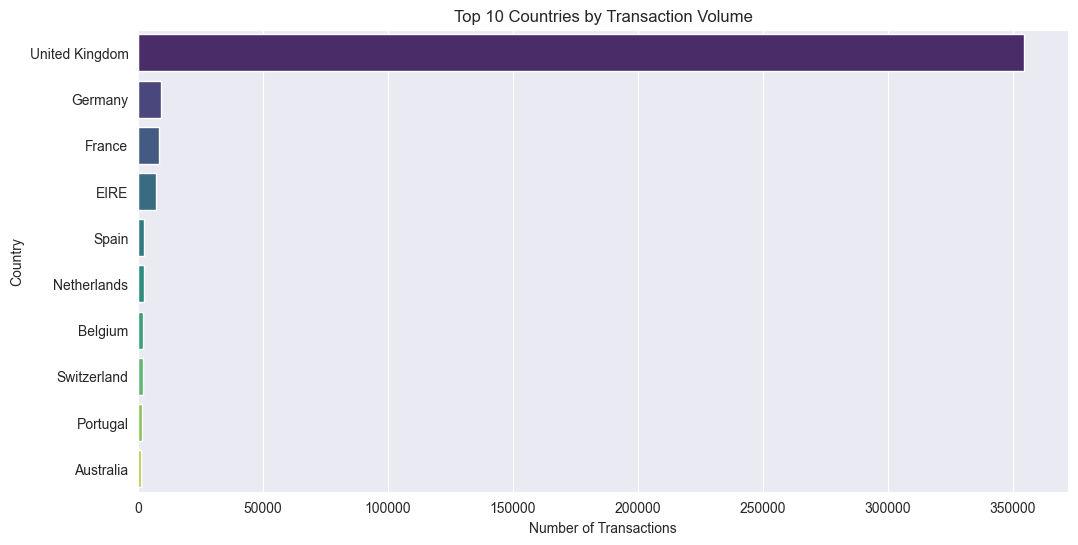

In [4]:
top_countries = df_clean['Country'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Transaction Volume')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.show()


### Top Selling Products


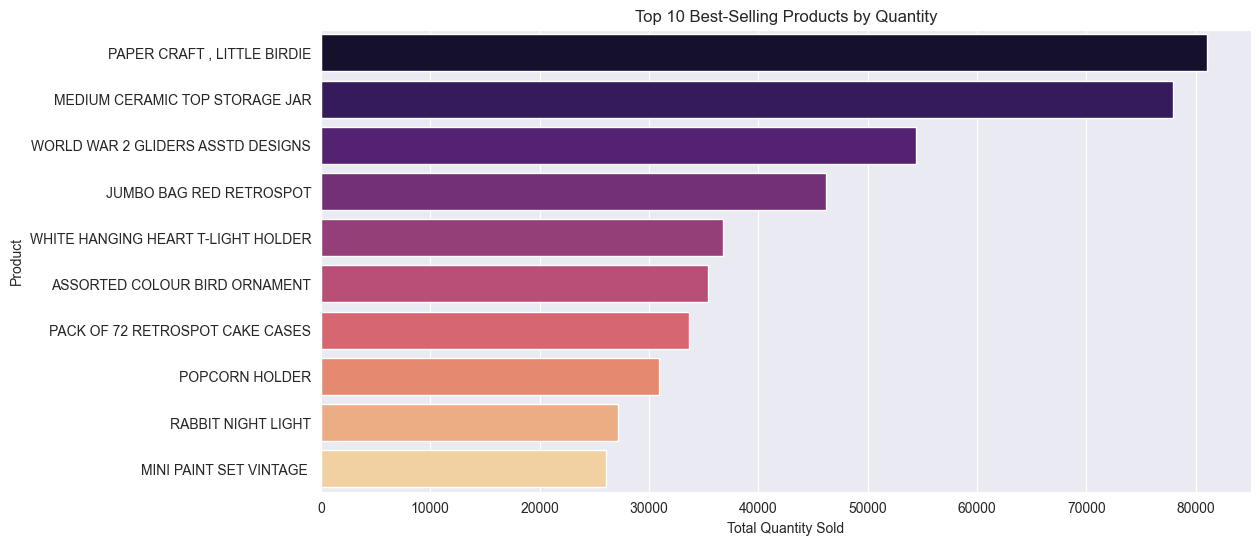

In [5]:
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.show()


## 4️⃣ RFM Feature Engineering
Calculate Recency, Frequency, and Monetary metrics for Customer Segmentation.


In [6]:
latest_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

display(rfm.head())


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


## 5️⃣ Customer Segmentation (K-Means Clustering)
We will use the Elbow Method and Silhouette Score to evaluate the optimal number of clusters.


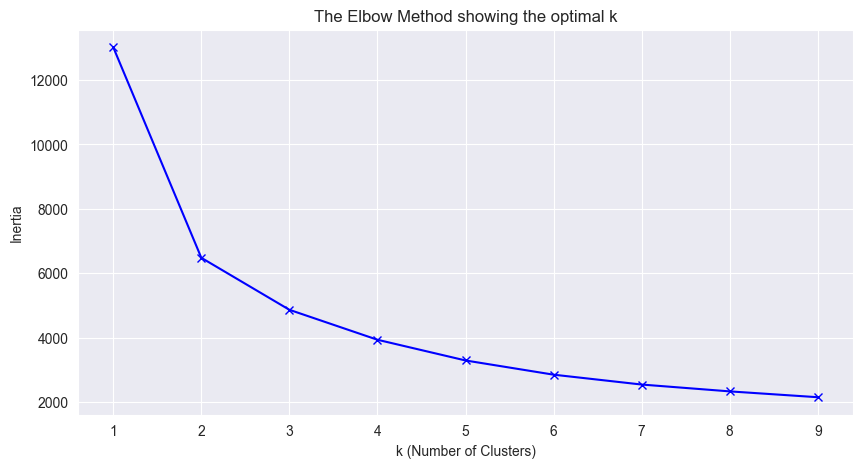

In [7]:
# Apply log transformation to handle right-skewness and extreme outliers
features = rfm[['Recency', 'Frequency', 'Monetary']]
features_log = np.log1p(features)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features_log)

# Elbow Method
inertia = []
K = range(1, 10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeanModel.fit(rfm_scaled)
    inertia.append(kmeanModel.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()


In [8]:
# Train the final KMeans model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Model Evaluation: Silhouette Score
sil_score = silhouette_score(rfm_scaled, kmeans.labels_)
print(f"Silhouette Score for k=4: {sil_score:.4f}")

# Map clusters logically based on Monetary value
cluster_avg = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
monetary_ranks = cluster_avg['Monetary'].rank(method='first').to_dict()
label_map = {4: 'High-Value', 3: 'Regular', 2: 'Occasional', 1: 'At-Risk'}
rfm['Segment'] = rfm['Cluster'].map(lambda x: label_map[monetary_ranks[x]])

display(rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2))


Silhouette Score for k=4: 0.3371


,Recency,Frequency,Monetary
Segment,,,
At-Risk,182.50,1.32,343.45
High-Value,12.13,13.71,8074.27
Occasional,18.12,2.15,551.82
Regular,71.08,4.08,1802.83


## 6️⃣ Product Recommendation System
Using Item-based Collaborative Filtering to recommend products based on Cosine Similarity.


In [9]:
# Select top 1000 items to avoid memory issues
top_items = df_clean['Description'].value_counts().head(1000).index
df_top = df_clean[df_clean['Description'].isin(top_items)]

# User-Item Matrix
user_item_matrix = df_top.pivot_table(index='CustomerID', columns='Description', values='Quantity', aggfunc='sum', fill_value=0)
user_item_matrix = user_item_matrix.map(lambda x: 1 if x > 0 else 0)

# Cosine Similarity
item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

def recommend_products(product_name, num_recommendations=5):
    if product_name not in item_similarity_df.index:
        return "Product not found."
    scores = item_similarity_df[product_name].sort_values(ascending=False)[1:num_recommendations+1]
    return scores

# Test the recommendation engine
test_product = item_similarity_df.index[0]
print(f"Recommendations for '{test_product}':")
print(recommend_products(test_product))


Recommendations for ' DOLLY GIRL BEAKER':
Description
SPACEBOY BEAKER              0.786742
DOLLY GIRL LUNCH BOX         0.460419
SPACEBOY LUNCH BOX           0.429104
DOLLY GIRL CHILDRENS CUP     0.392232
DOLLY GIRL CHILDRENS BOWL    0.389155
Name:  DOLLY GIRL BEAKER, dtype: float64
